# 05. Baseline Models

**Objective:**  
Train and evaluate multiple baseline classifiers to establish
performance benchmarks before advanced modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
from pathlib import Path

sns.set(style="whitegrid")


In [2]:
TRAIN_PATH = Path("../data/train_fe.csv")
TEST_PATH  = Path("../data/test_fe.csv")

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

X_train = train_df.drop(columns=["class"])
y_train = train_df["class"]

X_test = test_df.drop(columns=["class"])
y_test = test_df["class"]

print("✅ Feature-engineered data loaded")


✅ Feature-engineered data loaded


In [3]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "SVM (Linear)": SVC(kernel="linear", probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

print("📌 Baseline models defined:")
for name in models:
    print("-", name)


📌 Baseline models defined:
- Logistic Regression
- SVM (Linear)
- KNN


In [4]:
results = {}

for name, model in models.items():
    print(f"\n🚀 Training {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print("📋 Classification Report:")
    print(classification_report(y_test, y_pred))

    results[name] = (y_pred, y_prob)



🚀 Training Logistic Regression...
📋 Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.61      0.61       166
           1       0.88      0.86      0.87       169
           2       0.60      0.52      0.56       112
           3       0.91      0.86      0.89       172
           4       0.90      0.86      0.88       146
           5       0.94      0.92      0.93       163
           6       0.63      0.41      0.50        88
           7       0.80      0.78      0.79       134
           8       1.00      1.00      1.00       178
           9       0.93      0.96      0.94       147
          10       0.66      0.88      0.75        68
          11       0.91      0.86      0.88       173
          12       0.51      0.51      0.51       169
          13       0.74      0.80      0.77       125
          14       0.99      0.96      0.98       159
          15       0.91      0.93      0.92       148
          16       0.

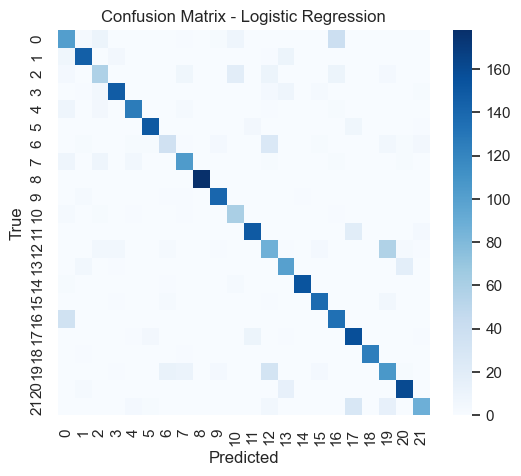

📊 Confusion matrix plotted


In [5]:
best_model_name = "Logistic Regression"
y_pred_best = results[best_model_name][0]

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("📊 Confusion matrix plotted")


In [6]:
y_test_bin = label_binarize(y_test, classes=range(22))
y_prob_best = results[best_model_name][1]

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob_best,
    multi_class="ovr"
)

print(f"🎯 ROC-AUC ({best_model_name}): {roc_auc:.4f}")


🎯 ROC-AUC (Logistic Regression): 0.9882
